## Setup

In [1]:
import os
from dotenv import load_dotenv
import random
import numpy as np
import pandas as pd
import torch
from pathlib import Path
from huggingface_hub import login

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ── Device ────────────────────────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

# ── Directory structure ───────────────────────────────────────────────────────
# Adjust DATA_DIR to where your .tsv/.csv files live
DATA_DIR       = Path('./data')
TALKDOWN_DIR   = Path('talkdown')          # see Block 3 for download instructions
CHECKPOINTS    = Path('checkpoints')
CHECKPOINTS.mkdir(exist_ok=True)

TALKDOWN_CKPT  = CHECKPOINTS / 'deberta_talkdown'
PCL_CKPT       = CHECKPOINTS / 'deberta_pcl_best'

# HF
load_dotenv()  # loads from .env in current directory
HF_TOKEN = os.getenv('HF_TOKEN')
assert HF_TOKEN is not None, '.env file missing or HF_TOKEN not set!'
login(token=HF_TOKEN)
print('HuggingFace authentication successful.')

print('Directories ready.')
print(f'TalkDown checkpoint path : {TALKDOWN_CKPT}')
print(f'PCL checkpoint path      : {PCL_CKPT}')

Device: cuda
GPU: NVIDIA GeForce RTX 4090


Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


HuggingFace authentication successful.
Directories ready.
TalkDown checkpoint path : checkpoints/deberta_talkdown
PCL checkpoint path      : checkpoints/deberta_pcl_best


## Data loading & Preprocess

In [2]:
import html, re

def clean_text(text) -> str:
    """Unescape HTML entities and strip residual tags. Handles NaN."""
    if not isinstance(text, str):
        return ''
    text = html.unescape(text)
    text = re.sub(r'<[^>]+>', '', text)
    return text.strip()

def add_keyword_prefix(row) -> str:
    """Prepend topic keyword as a bracketed token."""
    return f"[{row['keyword']}] {row['text']}"

# ── Load raw TSV ──────────────────────────────────────────────────────────────
df_raw = pd.read_csv(
    DATA_DIR / 'dontpatronizeme_pcl.tsv', sep='\t', header=None,
    names=['par_id','art_id','keyword','country','text','label']
)

# Drop disclaimer / separator rows
df_raw = df_raw[pd.to_numeric(df_raw['par_id'], errors='coerce').notna()].copy()
df_raw['par_id'] = df_raw['par_id'].astype(int)

# ── Load split IDs ────────────────────────────────────────────────────────────
train_ids = pd.read_csv(DATA_DIR / 'train_semeval_parids-labels.csv')
dev_ids   = pd.read_csv(DATA_DIR / 'dev_semeval_parids-labels.csv')

train = df_raw[df_raw['par_id'].isin(train_ids['par_id'])].copy()
dev   = df_raw[df_raw['par_id'].isin(dev_ids['par_id'])].copy()

# ── Binarise labels (0-4 scale → 0/1) ────────────────────────────────────────
train['label'] = (train['label'].astype(int) >= 1).astype(int)
dev['label']   = (dev['label'].astype(int) >= 1).astype(int)

# ── Clean text ────────────────────────────────────────────────────────────────
train['text'] = train['text'].apply(clean_text)
dev['text']   = dev['text'].apply(clean_text)

# ── Add keyword prefix ────────────────────────────────────────────────────────
train['text_input'] = train.apply(add_keyword_prefix, axis=1)
dev['text_input']   = dev.apply(add_keyword_prefix, axis=1)

# ── Sanity checks ─────────────────────────────────────────────────────────────
print(f'Train size : {len(train)}')
print(f'Dev size   : {len(dev)}')
print(f'Train label distribution:\n{train["label"].value_counts()}')
print(f'Dev label distribution:\n{dev["label"].value_counts()}')
print(f'\nSample input (train[0]):')
print(train['text_input'].iloc[0])
assert train['text'].isna().sum() == 0, 'NaN texts in train!'
assert dev['text'].isna().sum() == 0,   'NaN texts in dev!'
assert set(train['label'].unique()) == {0, 1}, 'Labels not binarised!'
print('\nAll sanity checks passed.')

Train size : 8375
Dev size   : 2094
Train label distribution:
label
0    6825
1    1550
Name: count, dtype: int64
Dev label distribution:
label
0    1704
1     390
Name: count, dtype: int64

Sample input (train[0]):
[hopeless] We 're living in times of absolute insanity , as I 'm pretty sure most people are aware . For a while , waking up every day to check the news seemed to carry with it the same feeling of panic and dread that action heroes probably face when they 're trying to decide whether to cut the blue or green wire on a ticking bomb -- except the bomb 's instructions long ago burned in a fire and imminent catastrophe seems the likeliest outcome . It 's hard to stay that on-edge for that long , though , so it 's natural for people to become inured to this constant chaos , to slump into a malaise of hopelessness and pessimism .

All sanity checks passed.


In [3]:
test = pd.read_csv(
    DATA_DIR / 'task4_test.tsv', sep='\t', header=None,
    names=['par_id', 'art_id', 'keyword', 'country', 'text']
)

# No disclaimer rows to filter — IDs are already clean (t_0, t_1, ...)
test['text'] = test['text'].apply(clean_text)
test['text_input'] = test.apply(add_keyword_prefix, axis=1)

print(f'Test size: {len(test)}')
print(f'Sample test input: {test["text_input"].iloc[0]}')
assert len(test) == 3832, f'Expected 3832 test rows, got {len(test)}'
assert test['text'].isna().sum() == 0, 'NaN texts in test!'
print('Test set loaded successfully.')

Test size: 3832
Sample test input: [vulnerable] In the meantime , conservatives are working to weaken Clinton and drive down her numbers in early voting states , where she is increasingly vulnerable . They are , in effect , doing Sanders 's dirty work for him while he avoids scrutiny .
Test set loaded successfully.


## Talkdown dataset

In [4]:
import urllib.request
import tarfile

# Download and extract TalkDown dataset
TALKDOWN_URL = 'https://cs.stanford.edu/people/zijwang/talkdown/talkdown.tar.gz'
TALKDOWN_TAR = Path('talkdown.tar.gz')

# ── Skip if already downloaded ────────────────────────────────────────────────
if (TALKDOWN_DIR / 'balanced_train.jsonl').exists():
    print('TalkDown already extracted — skipping download.')
else:
    TALKDOWN_DIR.mkdir(exist_ok=True)

    # Download
    print(f'Downloading TalkDown from {TALKDOWN_URL}...')
    urllib.request.urlretrieve(TALKDOWN_URL, TALKDOWN_TAR)
    print(f'Downloaded: {TALKDOWN_TAR} ({TALKDOWN_TAR.stat().st_size / 1e6:.1f} MB)')

    # Extract
    print('Extracting...')
    with tarfile.open(TALKDOWN_TAR, 'r:gz') as tar:
        tar.extractall(path=TALKDOWN_DIR)
    print(f'Extracted to {TALKDOWN_DIR}/')

    # Clean up tar file
    TALKDOWN_TAR.unlink()
    print('Removed tar file.')

    # Verify
    expected = ['balanced_train.jsonl', 'balanced_dev.jsonl', 'balanced_test.jsonl']
    for f in expected:
        # Search recursively in case tar extracted into a subdirectory
        matches = list(TALKDOWN_DIR.rglob(f))
        assert len(matches) > 0, f'{f} not found after extraction!'
        print(f'  ✓ {matches[0]}')

    print('TalkDown download and extraction complete.')

# ── Move files to talkdown/ root if extracted into subdirectory ───────────────
import shutil
for jsonl in TALKDOWN_DIR.rglob('*.jsonl'):
    target = TALKDOWN_DIR / jsonl.name
    if jsonl != target:
        shutil.move(str(jsonl), str(target))
        print(f'Moved {jsonl.name} to {target}')

print(f'Files in {TALKDOWN_DIR}/:')
for f in sorted(TALKDOWN_DIR.iterdir()):
    print(f'  {f.name}')

TalkDown already extracted — skipping download.
Files in talkdown/:
  README.md
  annotated.jsonl
  balanced_dev.jsonl
  balanced_test.jsonl
  balanced_train.jsonl
  imbalanced_dev.jsonl
  imbalanced_test.jsonl
  imbalanced_train.jsonl


In [5]:
import json

def load_jsonl(path):
    records = []
    with open(path, 'r') as f:
        for line in f:
            records.append(json.loads(line.strip()))
    return pd.DataFrame(records)

# assert files exist
assert (TALKDOWN_DIR / 'balanced_train.jsonl').exists(), 'TalkDown train file not found!'
assert (TALKDOWN_DIR / 'balanced_dev.jsonl').exists(), 'TalkDown dev file not found!'

td_train = load_jsonl(TALKDOWN_DIR / 'balanced_train.jsonl')
td_val   = load_jsonl(TALKDOWN_DIR / 'balanced_dev.jsonl')

# Use 'post' as text, convert bool label to int
td_train['text']  = td_train['post'].apply(clean_text)
td_train['label'] = td_train['label'].astype(int)
td_val['text']    = td_val['post'].apply(clean_text)
td_val['label']   = td_val['label'].astype(int)

td_train = td_train.dropna(subset=['text']).reset_index(drop=True)
td_val   = td_val.dropna(subset=['text']).reset_index(drop=True)

print(f'TalkDown train: {len(td_train)} | val: {len(td_val)}')
print(f'Label distribution:\n{td_train["label"].value_counts()}')
print(f'Sample: {td_train["text"].iloc[0][:100]}')

TalkDown train: 5208 | val: 650
Label distribution:
label
1    2604
0    2604
Name: count, dtype: int64
Sample: Well a guy is saying Barra, who has those great credentials, sucks... It is just so rude an misinfor


## Tokeniser & classes

In [6]:
from transformers import AutoTokenizer
from torch.utils.data import Dataset, DataLoader

MODEL_NAME = 'microsoft/deberta-v3-base'
MAX_LENGTH = 256

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class TextDataset(Dataset):
    def __init__(self, texts, labels=None, tokenizer=None, max_length=256):
        self.texts      = texts.tolist() if hasattr(texts, 'tolist') else list(texts)
        self.labels     = labels.tolist() if labels is not None else None
        self.tokenizer  = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            truncation    = True,
            max_length    = self.max_length,
            padding       = 'max_length',
            return_tensors= 'pt'
        )
        item = {
            'input_ids'     : encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
        }
        if 'token_type_ids' in encoding:
            item['token_type_ids'] = encoding['token_type_ids'].squeeze()
        if self.labels is not None:
            item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

# ── Sanity check tokeniser ────────────────────────────────────────────────────
sample = tokenizer(
    '[homeless] This is a test sentence.',
    truncation=True, max_length=MAX_LENGTH, return_tensors='pt'
)
print(f'Tokeniser loaded: {MODEL_NAME}')
print(f'Sample token count: {sample["input_ids"].shape[1]}')
print('Tokeniser sanity check passed.')

Tokeniser loaded: microsoft/deberta-v3-base
Sample token count: 10
Tokeniser sanity check passed.


## Utilities

In [9]:
import json
from transformers import AutoModelForSequenceClassification, get_linear_schedule_with_warmup
from torch.optim import AdamW
from torch.amp import GradScaler, autocast
from sklearn.metrics import f1_score, classification_report

# ── GPU optimisations for 4090 ────────────────────────────────────────────────
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32       = True
torch.backends.cudnn.benchmark        = True

def compute_f1(preds, labels, positive_label=1):
    return f1_score(labels, preds, pos_label=positive_label)

# ── Focal Loss ────────────────────────────────────────────────────────────────
class FocalLoss(torch.nn.Module):
    """
    Focal Loss for imbalanced classification.
    - alpha: weight for positive class (PCL). Higher = more focus on PCL.
    - gamma: focusing parameter. Higher = more focus on hard examples.
      gamma=0 reduces to weighted cross-entropy.
      gamma=2 is the standard value from the original paper.
    """
    def __init__(self, alpha=None, gamma=2.0, reduction='mean'):
        super().__init__()
        self.alpha     = alpha      # tensor of per-class weights
        self.gamma     = gamma
        self.reduction = reduction

    def forward(self, logits, labels):
        # Standard CE per sample
        ce_loss = torch.nn.functional.cross_entropy(
            logits, labels,
            weight=self.alpha,
            reduction='none'
        )
        # Probability of the true class
        pt      = torch.exp(-ce_loss)
        # Focal modulation — down-weights easy examples
        focal   = (1 - pt) ** self.gamma * ce_loss

        if self.reduction == 'mean':
            return focal.mean()
        elif self.reduction == 'sum':
            return focal.sum()
        return focal

def evaluate(model, dataloader, device):
    """Returns F1 on positive class, all predictions, and all labels."""
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in dataloader:
            input_ids      = batch['input_ids'].to(device, non_blocking=True)
            attention_mask = batch['attention_mask'].to(device, non_blocking=True)
            labels         = batch['labels'].to(device, non_blocking=True)
            kwargs = {'input_ids': input_ids, 'attention_mask': attention_mask}
            if 'token_type_ids' in batch:
                kwargs['token_type_ids'] = batch['token_type_ids'].to(device, non_blocking=True)
            with autocast(device_type='cuda'):
                outputs = model(**kwargs)
            preds = torch.argmax(outputs.logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    f1 = compute_f1(all_preds, all_labels)
    return f1, all_preds, all_labels

def save_training_metadata(save_path, epoch, best_f1):
    Path(save_path).mkdir(parents=True, exist_ok=True)
    meta = {'epochs_completed': epoch, 'best_f1': best_f1}
    with open(Path(save_path) / 'training_meta.json', 'w') as f:
        json.dump(meta, f)

def load_training_metadata(save_path):
    meta_path = Path(save_path) / 'training_meta.json'
    if meta_path.exists():
        with open(meta_path) as f:
            return json.load(f)
    return None

def train_model(
    model, train_loader, val_loader,
    n_epochs, lr, warmup_steps,
    device, save_path,
    class_weights=None,
    use_amp=True,
    gradient_accumulation_steps=1,
    resume_from_checkpoint=False,
    focal_gamma=2.0       # set to 0 to disable focal loss and use weighted CE
):
    # ── Checkpoint handling ───────────────────────────────────────────────────
    if Path(save_path).exists() and not resume_from_checkpoint:
        print(f'Checkpoint found at {save_path} — loading saved model, skipping training.')
        model = AutoModelForSequenceClassification.from_pretrained(save_path)
        model.to(device)
        return model

    start_epoch = 0

    if Path(save_path).exists() and resume_from_checkpoint:
        print(f'Resuming training from checkpoint: {save_path}')
        model = AutoModelForSequenceClassification.from_pretrained(save_path)
        model.to(device)
        meta = load_training_metadata(save_path)
        if meta is not None:
            start_epoch = meta['epochs_completed']
            best_f1     = meta['best_f1']
            print(f'Epochs already completed : {start_epoch}')
            print(f'Checkpoint val F1        : {best_f1:.4f}')
            if start_epoch >= n_epochs:
                print(f'Already completed {start_epoch} epochs — target is {n_epochs}. Nothing to do.')
                print('Increase NUM_EPOCHS to train further.')
                return model
            print(f'Resuming from epoch {start_epoch + 1} to {n_epochs} ({n_epochs - start_epoch} epochs remaining).')
        else:
            best_f1, _, _ = evaluate(model, val_loader, device)
            print(f'No metadata found. Checkpoint val F1: {best_f1:.4f}')
    else:
        print('No checkpoint found — starting training from scratch.')
        best_f1     = 0.0
        start_epoch = 0
        model.to(device)

    # ── Loss function — Focal Loss with class weights ─────────────────────────
    if class_weights is not None:
        alpha = torch.tensor(class_weights, dtype=torch.float).to(device)
    else:
        alpha = None

    loss_fn = FocalLoss(alpha=alpha, gamma=focal_gamma)
    print(f'Loss: FocalLoss(gamma={focal_gamma}, alpha={class_weights})')

    # ── Training setup ────────────────────────────────────────────────────────
    remaining_steps = len(train_loader) * (n_epochs - start_epoch)
    optimizer = AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps   = warmup_steps,
        num_training_steps = remaining_steps
    )
    scaler = GradScaler('cuda') if use_amp else None

    # ── Training loop ─────────────────────────────────────────────────────────
    for epoch in range(start_epoch, n_epochs):
        model.train()
        total_loss = 0
        optimizer.zero_grad()

        for step, batch in enumerate(train_loader):
            input_ids      = batch['input_ids'].to(device, non_blocking=True)
            attention_mask = batch['attention_mask'].to(device, non_blocking=True)
            labels         = batch['labels'].to(device, non_blocking=True)
            kwargs = {'input_ids': input_ids, 'attention_mask': attention_mask}
            if 'token_type_ids' in batch:
                kwargs['token_type_ids'] = batch['token_type_ids'].to(device, non_blocking=True)

            if use_amp:
                with autocast(device_type='cuda'):
                    outputs = model(**kwargs)
                    loss    = loss_fn(outputs.logits, labels)
                loss = loss / gradient_accumulation_steps
                scaler.scale(loss).backward()
                if (step + 1) % gradient_accumulation_steps == 0:
                    scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                    scaler.step(optimizer)
                    scaler.update()
                    scheduler.step()
                    optimizer.zero_grad()
            else:
                outputs = model(**kwargs)
                loss    = loss_fn(outputs.logits, labels)
                loss    = loss / gradient_accumulation_steps
                loss.backward()
                if (step + 1) % gradient_accumulation_steps == 0:
                    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                    optimizer.step()
                    scheduler.step()
                    optimizer.zero_grad()

            total_loss += loss.item() * gradient_accumulation_steps
            if step % 50 == 0:
                print(f'  Epoch {epoch+1} | Step {step}/{len(train_loader)} | Loss: {loss.item()*gradient_accumulation_steps:.4f}')

        avg_loss = total_loss / len(train_loader)
        val_f1, _, _ = evaluate(model, val_loader, device)
        print(f'Epoch {epoch+1}/{n_epochs} | Avg Loss: {avg_loss:.4f} | Val F1: {val_f1:.4f}')

        save_training_metadata(save_path, epoch + 1, best_f1)

        if val_f1 > best_f1:
            best_f1 = val_f1
            model.save_pretrained(save_path)
            tokenizer.save_pretrained(save_path)
            save_training_metadata(save_path, epoch + 1, best_f1)
            print(f'  ✓ New best model saved (F1={best_f1:.4f})')

    print(f'Training complete. Best val F1: {best_f1:.4f}')
    return model

print('Training utilities loaded.')

Training utilities loaded.


## Stage 1: fine tune on TalkDown

In [10]:
if not (TALKDOWN_DIR / 'balanced_train.jsonl').exists():
    print('TalkDown dataset not found — skipping Stage 1.')
elif TALKDOWN_CKPT.exists():
    print(f'TalkDown checkpoint found — loading saved model, skipping training.')
    td_model = AutoModelForSequenceClassification.from_pretrained(
        TALKDOWN_CKPT,
        num_labels=2,
        dtype=torch.float32
    )
    td_model.to(DEVICE)
    print(f'Stage 1 complete. Loaded from: {TALKDOWN_CKPT}')
else:
    # ── Clear GPU memory ─────────────────────────────────────────────────────
    import gc
    gc.collect()
    torch.cuda.empty_cache()
    # ── Filter out empty/null texts ──────────────────────────────────────────
    td_train = td_train[td_train['text'].str.strip().str.len() > 5].reset_index(drop=True)
    td_val   = td_val[td_val['text'].str.strip().str.len() > 5].reset_index(drop=True)
    print(f'TalkDown train after filtering: {len(td_train)}')
    print(f'TalkDown val after filtering  : {len(td_val)}')
    # ── Check for NaN labels ─────────────────────────────────────────────────
    assert td_train['label'].isna().sum() == 0, 'NaN labels in TalkDown train!'
    assert set(td_train['label'].unique()).issubset({0, 1}), f'Unexpected labels: {td_train["label"].unique()}'
    print(f'Label distribution:\n{td_train["label"].value_counts()}')
    BATCH_SIZE_TD = 8
    td_train_dataset = TextDataset(td_train['text'], td_train['label'], tokenizer, MAX_LENGTH)
    td_val_dataset   = TextDataset(td_val['text'],   td_val['label'],   tokenizer, MAX_LENGTH)
    td_train_loader  = DataLoader(td_train_dataset, batch_size=BATCH_SIZE_TD, shuffle=True, drop_last=True)
    td_val_loader    = DataLoader(td_val_dataset,   batch_size=BATCH_SIZE_TD, drop_last=False)
    # ── Sanity check: verify no NaN in first batch ───────────────────────────
    sample_batch = next(iter(td_train_loader))
    print(f'Batch input_ids shape : {sample_batch["input_ids"].shape}')
    print(f'Batch labels          : {sample_batch["labels"][:8]}')
    assert not torch.isnan(sample_batch['input_ids'].float()).any(), 'NaN in input_ids!'
    # ── Load fresh DeBERTa ────────────────────────────────────────────────────
    td_model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=2, dtype=torch.float32
    )
    for name, param in td_model.named_parameters():
        if torch.isnan(param).any():
            print(f'NaN in parameter: {name}')
            break
    else:
        print('Model parameters clean — no NaN detected.')
    print('Starting Stage 1: TalkDown fine-tuning...')
    td_model = train_model(
        model         = td_model,
        train_loader  = td_train_loader,
        val_loader    = td_val_loader,
        n_epochs      = 3,
        lr            = 5e-6,
        warmup_steps  = 200,
        device        = DEVICE,
        save_path     = TALKDOWN_CKPT,
        class_weights = None
    )
    assert TALKDOWN_CKPT.exists(), 'TalkDown checkpoint not saved!'
    print(f'Stage 1 complete. Checkpoint: {TALKDOWN_CKPT}')

TalkDown train after filtering: 5207
TalkDown val after filtering  : 650
Label distribution:
label
1    2604
0    2603
Name: count, dtype: int64
Batch input_ids shape : torch.Size([8, 256])
Batch labels          : tensor([1, 1, 0, 1, 0, 1, 1, 1])


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     | 
----------------------------------------+------------+-
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
pooler.dense.bias                       | MISSING    | 
classifier.weight                       | MISSING    | 
classifier.bias                         | MISSING    | 
pooler.dense.weight      

Model parameters clean — no NaN detected.
Starting Stage 1: TalkDown fine-tuning...
No checkpoint found — starting training from scratch.
Loss: FocalLoss(gamma=2.0, alpha=None)
  Epoch 1 | Step 0/650 | Loss: 0.1842
  Epoch 1 | Step 50/650 | Loss: 0.2272
  Epoch 1 | Step 100/650 | Loss: 0.2047
  Epoch 1 | Step 150/650 | Loss: 0.1884
  Epoch 1 | Step 200/650 | Loss: 0.1687
  Epoch 1 | Step 250/650 | Loss: 0.1749
  Epoch 1 | Step 300/650 | Loss: 0.1812
  Epoch 1 | Step 350/650 | Loss: 0.1828
  Epoch 1 | Step 400/650 | Loss: 0.1850
  Epoch 1 | Step 450/650 | Loss: 0.1981
  Epoch 1 | Step 500/650 | Loss: 0.1808
  Epoch 1 | Step 550/650 | Loss: 0.1708
  Epoch 1 | Step 600/650 | Loss: 0.1713
Epoch 1/3 | Avg Loss: 0.1773 | Val F1: 0.6764


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✓ New best model saved (F1=0.6764)
  Epoch 2 | Step 0/650 | Loss: 0.1729
  Epoch 2 | Step 50/650 | Loss: 0.1612
  Epoch 2 | Step 100/650 | Loss: 0.1781
  Epoch 2 | Step 150/650 | Loss: 0.1662
  Epoch 2 | Step 200/650 | Loss: 0.1970
  Epoch 2 | Step 250/650 | Loss: 0.1893
  Epoch 2 | Step 300/650 | Loss: 0.2278
  Epoch 2 | Step 350/650 | Loss: 0.1160
  Epoch 2 | Step 400/650 | Loss: 0.1287
  Epoch 2 | Step 450/650 | Loss: 0.0941
  Epoch 2 | Step 500/650 | Loss: 0.2067
  Epoch 2 | Step 550/650 | Loss: 0.2207
  Epoch 2 | Step 600/650 | Loss: 0.1257
Epoch 2/3 | Avg Loss: 0.1671 | Val F1: 0.6667
  Epoch 3 | Step 0/650 | Loss: 0.1902
  Epoch 3 | Step 50/650 | Loss: 0.1480
  Epoch 3 | Step 100/650 | Loss: 0.1819
  Epoch 3 | Step 150/650 | Loss: 0.2155
  Epoch 3 | Step 200/650 | Loss: 0.0940
  Epoch 3 | Step 250/650 | Loss: 0.1256
  Epoch 3 | Step 300/650 | Loss: 0.1665
  Epoch 3 | Step 350/650 | Loss: 0.1242
  Epoch 3 | Step 400/650 | Loss: 0.1498
  Epoch 3 | Step 450/650 | Loss: 0.1226
  E

## Fine-tune on PCL

In [11]:
from torch.utils.data import WeightedRandomSampler
from torch.amp import GradScaler, autocast

# ── GPU optimisations for 4090 ────────────────────────────────────────────────
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32       = True
torch.backends.cudnn.benchmark        = True

BATCH_SIZE_PCL = 32   # 4090 24GB can handle this comfortably
NUM_WORKERS    = 4
NUM_EPOCHS     = 8    # more epochs for PCL fine-tuning, best ckpt auto-saved

# ── Class weights (4.4:1 imbalance) ──────────────────────────────────────────
n_neg     = (train['label'] == 0).sum()
n_pos     = (train['label'] == 1).sum()
w_neg     = 1.0
w_pos     = n_neg / n_pos
CLASS_WEIGHTS = [w_neg, w_pos]
print(f'Class weights: No PCL={w_neg:.2f}, PCL={w_pos:.2f}')

# ── Datasets ──────────────────────────────────────────────────────────────────
train_dataset = TextDataset(train['text_input'], train['label'], tokenizer, MAX_LENGTH)
dev_dataset   = TextDataset(dev['text_input'],   dev['label'],   tokenizer, MAX_LENGTH)

train_loader = DataLoader(
    train_dataset,
    batch_size  = BATCH_SIZE_PCL,
    shuffle     = True,
    num_workers = NUM_WORKERS,
    pin_memory  = True
)
dev_loader = DataLoader(
    dev_dataset,
    batch_size  = BATCH_SIZE_PCL * 2,
    num_workers = NUM_WORKERS,
    pin_memory  = True
)

# ── Sanity check ──────────────────────────────────────────────────────────────
sample_batch = next(iter(train_loader))
print(f'PCL batch input_ids shape : {sample_batch["input_ids"].shape}')
print(f'PCL batch labels (first 8): {sample_batch["labels"][:8]}')
assert sample_batch['input_ids'].shape[1] == MAX_LENGTH, 'Wrong max_length!'

# ── Load from TalkDown checkpoint (or fresh DeBERTa if skipped) ───────────────
if TALKDOWN_CKPT.exists():
    print(f'Loading TalkDown checkpoint from {TALKDOWN_CKPT}')
    pcl_model = AutoModelForSequenceClassification.from_pretrained(
        TALKDOWN_CKPT, num_labels=2,
        ignore_mismatched_sizes=True,
        torch_dtype=torch.float32
    )
else:
    print('No TalkDown checkpoint found — loading fresh DeBERTa.')
    pcl_model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=2, torch_dtype=torch.float32
    )

print('Starting Stage 2: PCL fine-tuning...')
pcl_model = train_model(
    model         = pcl_model,
    train_loader  = train_loader,
    val_loader    = dev_loader,
    n_epochs      = NUM_EPOCHS,
    lr            = 2e-5,    # slightly higher LR suits larger batch
    warmup_steps  = 150,
    device        = DEVICE,
    save_path     = PCL_CKPT,
    class_weights = CLASS_WEIGHTS,
    use_amp       = True,    # mixed precision — faster on 4090,
    focal_gamma   = 2.0,    # set to 0 to revert to weighted CE
    resume_from_checkpoint=False # resume training from checkpoint
)

assert PCL_CKPT.exists(), 'PCL checkpoint not saved!'
print(f'Stage 2 complete. Checkpoint: {PCL_CKPT}')

Class weights: No PCL=1.00, PCL=4.40


`torch_dtype` is deprecated! Use `dtype` instead!


PCL batch input_ids shape : torch.Size([32, 256])
PCL batch labels (first 8): tensor([0, 0, 0, 0, 0, 0, 0, 0])
Loading TalkDown checkpoint from checkpoints/deberta_talkdown


Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

Starting Stage 2: PCL fine-tuning...
No checkpoint found — starting training from scratch.
Loss: FocalLoss(gamma=2.0, alpha=[1.0, np.float64(4.403225806451613)])
  Epoch 1 | Step 0/262 | Loss: 0.8754
  Epoch 1 | Step 50/262 | Loss: 0.6630
  Epoch 1 | Step 100/262 | Loss: 0.4336
  Epoch 1 | Step 150/262 | Loss: 0.6724
  Epoch 1 | Step 200/262 | Loss: 0.4263
  Epoch 1 | Step 250/262 | Loss: 0.4544
Epoch 1/8 | Avg Loss: 0.5495 | Val F1: 0.5035


...

  ✓ New best model saved (F1=0.5729)
  Epoch 6 | Step 0/262 | Loss: 0.1726
  Epoch 6 | Step 50/262 | Loss: 0.2801
  Epoch 6 | Step 100/262 | Loss: 0.2487
  Epoch 6 | Step 150/262 | Loss: 0.3752
  Epoch 6 | Step 200/262 | Loss: 0.0973
  Epoch 6 | Step 250/262 | Loss: 0.3452
Epoch 6/8 | Avg Loss: 0.2359 | Val F1: 0.5652
  Epoch 7 | Step 0/262 | Loss: 0.1725
  Epoch 7 | Step 50/262 | Loss: 0.2296
  Epoch 7 | Step 100/262 | Loss: 0.3679
  Epoch 7 | Step 150/262 | Loss: 0.1842
  Epoch 7 | Step 200/262 | Loss: 0.4973
  Epoch 7 | Step 250/262 | Loss: 0.0525
Epoch 7/8 | Avg Loss: 0.2006 | Val F1: 0.5892


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✓ New best model saved (F1=0.5892)
  Epoch 8 | Step 0/262 | Loss: 0.0513
  Epoch 8 | Step 50/262 | Loss: 0.2472
  Epoch 8 | Step 100/262 | Loss: 0.0848
  Epoch 8 | Step 150/262 | Loss: 0.2421
  Epoch 8 | Step 200/262 | Loss: 0.0996
  Epoch 8 | Step 250/262 | Loss: 0.2658
Epoch 8/8 | Avg Loss: 0.1711 | Val F1: 0.6008


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✓ New best model saved (F1=0.6008)
Training complete. Best val F1: 0.6008
Stage 2 complete. Checkpoint: checkpoints/deberta_pcl_best


## load best model and eval on dev set

In [12]:
from sklearn.metrics import classification_report, confusion_matrix

# ── Load best PCL checkpoint ──────────────────────────────────────────────────
best_model = AutoModelForSequenceClassification.from_pretrained(PCL_CKPT)
best_model.to(DEVICE)
print(f'Loaded best model from {PCL_CKPT}')

# ── Evaluate ──────────────────────────────────────────────────────────────────
dev_f1, dev_preds, dev_labels = evaluate(best_model, dev_loader, DEVICE)

print(f'\n=== DEV SET EVALUATION ===')
print(f'F1 (PCL class): {dev_f1:.4f}')
print(f'Baseline F1   : 0.48')
print(f'Delta         : {dev_f1 - 0.48:+.4f}')
print(f'\n=== CLASSIFICATION REPORT ===')
print(classification_report(dev_labels, dev_preds, target_names=['No PCL', 'PCL']))
print(f'\n=== CONFUSION MATRIX ===')
print(confusion_matrix(dev_labels, dev_preds))

# ── Sanity check ──────────────────────────────────────────────────────────────
assert len(dev_preds) == len(dev), f'Prediction count mismatch: {len(dev_preds)} vs {len(dev)}'
assert set(dev_preds).issubset({0, 1}), 'Predictions contain values other than 0 and 1!'
print('\nEvaluation sanity checks passed.')

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

Loaded best model from checkpoints/deberta_pcl_best

=== DEV SET EVALUATION ===
F1 (PCL class): 0.6008
Baseline F1   : 0.48
Delta         : +0.1208

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

      No PCL       0.93      0.84      0.88      1704
         PCL       0.51      0.73      0.60       390

    accuracy                           0.82      2094
   macro avg       0.72      0.78      0.74      2094
weighted avg       0.85      0.82      0.83      2094


=== CONFUSION MATRIX ===
[[1435  269]
 [ 107  283]]

Evaluation sanity checks passed.


### Threshold tuning

In [13]:
from sklearn.metrics import f1_score
import numpy as np

# ── Load best model from checkpoint ──────────────────────────────────────────
best_model = AutoModelForSequenceClassification.from_pretrained(PCL_CKPT)
best_model.to(DEVICE)
best_model.eval()
print(f'Loaded best model from {PCL_CKPT}')

# Get raw probabilities
all_probs  = []
all_labels = []

with torch.no_grad():
    for batch in dev_loader:
        outputs = best_model(
            input_ids      = batch['input_ids'].to(DEVICE),
            attention_mask = batch['attention_mask'].to(DEVICE)
        )
        probs = torch.softmax(outputs.logits, dim=1)[:, 1]
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(batch['labels'].numpy())

all_probs  = np.array(all_probs)
all_labels = np.array(all_labels)

# Search for best threshold
best_f1, best_thresh = 0, 0.5
for thresh in np.arange(0.2, 0.8, 0.01):
    preds = (all_probs >= thresh).astype(int)
    f1    = f1_score(all_labels, preds, pos_label=1)
    if f1 > best_f1:
        best_f1, best_thresh = f1, thresh

print(f'Default threshold (0.5) F1 : {f1_score(all_labels, (all_probs>=0.5).astype(int), pos_label=1):.4f}')
print(f'Optimal threshold          : {best_thresh:.2f}')
print(f'Optimal threshold F1       : {best_f1:.4f}')

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

Loaded best model from checkpoints/deberta_pcl_best
Default threshold (0.5) F1 : 0.6008
Optimal threshold          : 0.61
Optimal threshold F1       : 0.6093


## Submission files

In [14]:
SUBMISSION_DIR = Path('.')

# ── Dev predictions ───────────────────────────────────────────────────────────
dev_out = SUBMISSION_DIR / 'dev.txt'
with open(dev_out, 'w') as f:
    for pred in dev_preds:
        f.write(f'{pred}\n')

# ── Test predictions ──────────────────────────────────────────────────────────
test_dataset = TextDataset(test['text_input'], labels=None, tokenizer=tokenizer, max_length=MAX_LENGTH)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE_PCL)

best_model.eval()
test_preds = []
with torch.no_grad():
    for batch in test_loader:
        input_ids      = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        kwargs = {'input_ids': input_ids, 'attention_mask': attention_mask}
        if 'token_type_ids' in batch:
            kwargs['token_type_ids'] = batch['token_type_ids'].to(DEVICE)
        outputs = best_model(**kwargs)
        preds   = torch.argmax(outputs.logits, dim=1)
        test_preds.extend(preds.cpu().numpy())

test_out = SUBMISSION_DIR / 'test.txt'
with open(test_out, 'w') as f:
    for pred in test_preds:
        f.write(f'{pred}\n')

# ── Sanity checks ─────────────────────────────────────────────────────────────
with open(dev_out)  as f: dev_lines  = f.readlines()
with open(test_out) as f: test_lines = f.readlines()

assert len(dev_lines)  == len(dev),  f'dev.txt has {len(dev_lines)} lines, expected {len(dev)}'
assert len(test_lines) == len(test), f'test.txt has {len(test_lines)} lines, expected {len(test)}'
assert all(l.strip() in {'0','1'} for l in dev_lines),  'dev.txt contains invalid predictions!'
assert all(l.strip() in {'0','1'} for l in test_lines), 'test.txt contains invalid predictions!'

print(f'dev.txt  : {len(dev_lines)} lines  — saved to {dev_out}')
print(f'test.txt : {len(test_lines)} lines — saved to {test_out}')
print(f'Dev PCL predictions  : {sum(int(l) for l in dev_lines)} positive')
print(f'Test PCL predictions : {sum(int(l) for l in test_lines)} positive')
print('\nAll submission sanity checks passed. Ready to push to GitHub.')

dev.txt  : 2094 lines  — saved to dev.txt
test.txt : 3832 lines — saved to test.txt
Dev PCL predictions  : 552 positive
Test PCL predictions : 972 positive

All submission sanity checks passed. Ready to push to GitHub.


## Ablation

no talkdown

In [15]:
ABLATION_CKPT = CHECKPOINTS / 'deberta_pcl_no_talkdown'

# ── Load fresh DeBERTa (no TalkDown intermediate step) ────────────────────────
ablation_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=2, torch_dtype=torch.float32
)

print('Starting ablation: direct PCL fine-tuning (no TalkDown)...')
ablation_model = train_model(
    model         = ablation_model,
    train_loader  = train_loader,
    val_loader    = dev_loader,
    n_epochs      = NUM_EPOCHS,
    lr            = 2e-5,
    warmup_steps  = 150,
    device        = DEVICE,
    save_path     = ABLATION_CKPT,
    class_weights = CLASS_WEIGHTS,
    use_amp       = True,
    resume_from_checkpoint=False
)

# ── Evaluate ──────────────────────────────────────────────────────────────────
ablation_model_loaded = AutoModelForSequenceClassification.from_pretrained(ABLATION_CKPT)
ablation_model_loaded.to(DEVICE)
abl_f1, abl_preds, abl_labels = evaluate(ablation_model_loaded, dev_loader, DEVICE)

print(f'\n=== ABLATION RESULTS ===')
print(f'Baseline (RoBERTa)             : F1 = 0.48')
print(f'DeBERTa direct (no TalkDown)   : F1 = {abl_f1:.4f}')
print(f'DeBERTa + TalkDown (BestModel) : F1 = {dev_f1:.4f}')
print(f'TalkDown contribution          : {dev_f1 - abl_f1:+.4f}')

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     | 
----------------------------------------+------------+-
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
pooler.dense.bias                       | MISSING    | 
classifier.weight                       | MISSING    | 
classifier.bias                         | MISSING    | 
pooler.dense.weight      

Starting ablation: direct PCL fine-tuning (no TalkDown)...
No checkpoint found — starting training from scratch.
Loss: FocalLoss(gamma=2.0, alpha=[1.0, np.float64(4.403225806451613)])


/tmp/ipykernel_24522/3509245381.py:168: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


  Epoch 1 | Step 0/262 | Loss: 0.4842
  Epoch 1 | Step 50/262 | Loss: 0.4538
  Epoch 1 | Step 100/262 | Loss: 0.5639
  Epoch 1 | Step 150/262 | Loss: 0.6736
  Epoch 1 | Step 200/262 | Loss: 0.3677
  Epoch 1 | Step 250/262 | Loss: 0.6055
Epoch 1/8 | Avg Loss: 0.5462 | Val F1: 0.5422


...

  ✓ New best model saved (F1=0.6057)
  Epoch 8 | Step 0/262 | Loss: 0.0590
  Epoch 8 | Step 50/262 | Loss: 0.4355
  Epoch 8 | Step 100/262 | Loss: 0.3141
  Epoch 8 | Step 150/262 | Loss: 0.3891
  Epoch 8 | Step 200/262 | Loss: 0.0584
  Epoch 8 | Step 250/262 | Loss: 0.1118
Epoch 8/8 | Avg Loss: 0.1596 | Val F1: 0.6114


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✓ New best model saved (F1=0.6114)
Training complete. Best val F1: 0.6114


Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]


=== ABLATION RESULTS ===
Baseline (RoBERTa)             : F1 = 0.48
DeBERTa direct (no TalkDown)   : F1 = 0.6114
DeBERTa + TalkDown (BestModel) : F1 = 0.6008
TalkDown contribution          : -0.0106


no keyword prefix - ablation study

In [16]:
# Train without keyword prefix — use raw text instead
train_no_prefix = train.copy()
train_no_prefix['text_input'] = train_no_prefix['text']  # no keyword prefix
dev_no_prefix   = dev.copy()
dev_no_prefix['text_input']   = dev_no_prefix['text']

train_dataset_np = TextDataset(train_no_prefix['text_input'], train_no_prefix['label'], tokenizer, MAX_LENGTH)
dev_dataset_np   = TextDataset(dev_no_prefix['text_input'],   dev_no_prefix['label'],   tokenizer, MAX_LENGTH)

train_loader_np = DataLoader(train_dataset_np, batch_size=BATCH_SIZE_PCL, shuffle=True,
                             num_workers=NUM_WORKERS, pin_memory=True)
dev_loader_np   = DataLoader(dev_dataset_np,   batch_size=BATCH_SIZE_PCL*2,
                             num_workers=NUM_WORKERS, pin_memory=True)

NO_PREFIX_CKPT = CHECKPOINTS / 'deberta_pcl_no_prefix'

no_prefix_model = AutoModelForSequenceClassification.from_pretrained(
    TALKDOWN_CKPT, num_labels=2,
    ignore_mismatched_sizes=True, torch_dtype=torch.float32
)
no_prefix_model = train_model(
    model         = no_prefix_model,
    train_loader  = train_loader_np,
    val_loader    = dev_loader_np,
    n_epochs      = NUM_EPOCHS,
    lr            = 2e-5,
    warmup_steps  = 150,
    device        = DEVICE,
    save_path     = NO_PREFIX_CKPT,
    class_weights = CLASS_WEIGHTS,
    use_amp       = True
)

np_model_loaded = AutoModelForSequenceClassification.from_pretrained(NO_PREFIX_CKPT)
np_model_loaded.to(DEVICE)
np_f1, _, _ = evaluate(np_model_loaded, dev_loader_np, DEVICE)

print(f'\n=== FULL ABLATION RESULTS ===')
print(f'Baseline (RoBERTa)                    : F1 = 0.48')
print(f'DeBERTa − TalkDown − keyword prefix   : F1 = {abl_f1:.4f}')
print(f'DeBERTa + TalkDown − keyword prefix   : F1 = {np_f1:.4f}')
print(f'DeBERTa + TalkDown + keyword prefix   : F1 = {dev_f1:.4f}  ← BestModel')
print(f'\nTalkDown contribution                 : {dev_f1 - np_f1:+.4f}')
print(f'Keyword prefix contribution           : {np_f1 - abl_f1:+.4f}')
print(f'Total gain over baseline              : {dev_f1 - 0.48:+.4f}')

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

No checkpoint found — starting training from scratch.
Loss: FocalLoss(gamma=2.0, alpha=[1.0, np.float64(4.403225806451613)])
  Epoch 1 | Step 0/262 | Loss: 0.5948
  Epoch 1 | Step 50/262 | Loss: 0.6447
  Epoch 1 | Step 100/262 | Loss: 0.6926
  Epoch 1 | Step 150/262 | Loss: 0.9569
  Epoch 1 | Step 200/262 | Loss: 0.3856
  Epoch 1 | Step 250/262 | Loss: 0.5581
Epoch 1/8 | Avg Loss: 0.5580 | Val F1: 0.4885


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✓ New best model saved (F1=0.4885)
  Epoch 2 | Step 0/262 | Loss: 0.4485
  Epoch 2 | Step 50/262 | Loss: 0.7046
  Epoch 2 | Step 100/262 | Loss: 0.3973
  Epoch 2 | Step 150/262 | Loss: 0.3557
  Epoch 2 | Step 200/262 | Loss: 0.3063
  Epoch 2 | Step 250/262 | Loss: 0.5239
Epoch 2/8 | Avg Loss: 0.4343 | Val F1: 0.5468


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

  ✓ New best model saved (F1=0.5830)
  Epoch 7 | Step 0/262 | Loss: 0.2535
  Epoch 7 | Step 50/262 | Loss: 0.0812
  Epoch 7 | Step 100/262 | Loss: 0.0853
  Epoch 7 | Step 150/262 | Loss: 0.0879
  Epoch 7 | Step 200/262 | Loss: 0.1459
  Epoch 7 | Step 250/262 | Loss: 0.0196
Epoch 7/8 | Avg Loss: 0.1588 | Val F1: 0.5842


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✓ New best model saved (F1=0.5842)
  Epoch 8 | Step 0/262 | Loss: 0.0225
  Epoch 8 | Step 50/262 | Loss: 0.0894
  Epoch 8 | Step 100/262 | Loss: 0.0274
  Epoch 8 | Step 150/262 | Loss: 0.1082
  Epoch 8 | Step 200/262 | Loss: 0.0154
  Epoch 8 | Step 250/262 | Loss: 0.2915
Epoch 8/8 | Avg Loss: 0.1350 | Val F1: 0.5789
Training complete. Best val F1: 0.5842


Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]


=== FULL ABLATION RESULTS ===
Baseline (RoBERTa)                    : F1 = 0.48
DeBERTa − TalkDown − keyword prefix   : F1 = 0.6114
DeBERTa + TalkDown − keyword prefix   : F1 = 0.5842
DeBERTa + TalkDown + keyword prefix   : F1 = 0.6008  ← BestModel

TalkDown contribution                 : +0.0166
Keyword prefix contribution           : -0.0272
Total gain over baseline              : +0.1208


## Error analysis

In [17]:
best_model = AutoModelForSequenceClassification.from_pretrained(PCL_CKPT)
best_model.to(DEVICE)

# Get all predictions with probabilities
all_probs, all_preds, all_labels_list = [], [], []
best_model.eval()
with torch.no_grad():
    for batch in dev_loader:
        outputs = best_model(
            input_ids      = batch['input_ids'].to(DEVICE),
            attention_mask = batch['attention_mask'].to(DEVICE)
        )
        probs = torch.softmax(outputs.logits, dim=1)[:, 1]
        preds = torch.argmax(outputs.logits, dim=1)
        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_labels_list.extend(batch['labels'].numpy())

dev_results = dev.copy().reset_index(drop=True)
dev_results['pred']       = all_preds
dev_results['prob_pcl']   = all_probs
dev_results['correct']    = (dev_results['pred'] == dev_results['label'])

# False positives — predicted PCL but actually No PCL
fp = dev_results[(dev_results['pred']==1) & (dev_results['label']==0)]
# False negatives — predicted No PCL but actually PCL  
fn = dev_results[(dev_results['pred']==0) & (dev_results['label']==1)]

print(f'False Positives: {len(fp)}')
print(f'False Negatives: {len(fn)}')

# Topic breakdown of errors
print('\n=== FALSE POSITIVE RATE BY TOPIC ===')
print(dev_results[dev_results['label']==0].groupby('keyword').apply(
    lambda x: (x['pred']==1).mean()
).sort_values(ascending=False).round(3))

print('\n=== FALSE NEGATIVE RATE BY TOPIC ===')
print(dev_results[dev_results['label']==1].groupby('keyword').apply(
    lambda x: (x['pred']==0).mean()
).sort_values(ascending=False).round(3))

# High confidence errors — most interesting for analysis
print('\n=== TOP 10 HIGH CONFIDENCE FALSE POSITIVES ===')
print(fp.nlargest(10, 'prob_pcl')[['text', 'keyword', 'prob_pcl']].to_string())

print('\n=== TOP 10 HIGH CONFIDENCE FALSE NEGATIVES ===')
print(fn.nsmallest(10, 'prob_pcl')[['text', 'keyword', 'prob_pcl']].to_string())

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

False Positives: 269
False Negatives: 107

=== FALSE POSITIVE RATE BY TOPIC ===
keyword
homeless         0.301
poor-families    0.283
hopeless         0.217
in-need          0.177
disabled         0.175
refugee          0.142
women            0.139
vulnerable       0.137
immigrant        0.053
migrant          0.052
dtype: float64

=== FALSE NEGATIVE RATE BY TOPIC ===
keyword
immigrant        0.500
women            0.484
migrant          0.438
poor-families    0.351
homeless         0.288
disabled         0.286
refugee          0.231
hopeless         0.179
vulnerable       0.147
in-need          0.118
dtype: float64

=== TOP 10 HIGH CONFIDENCE FALSE POSITIVES ===
                                                                                                                                                                                                                                                                                                                                        

### Custom metrics

FileNotFoundError: [Errno 2] No such file or directory: 'figures/pr_curve.pdf'

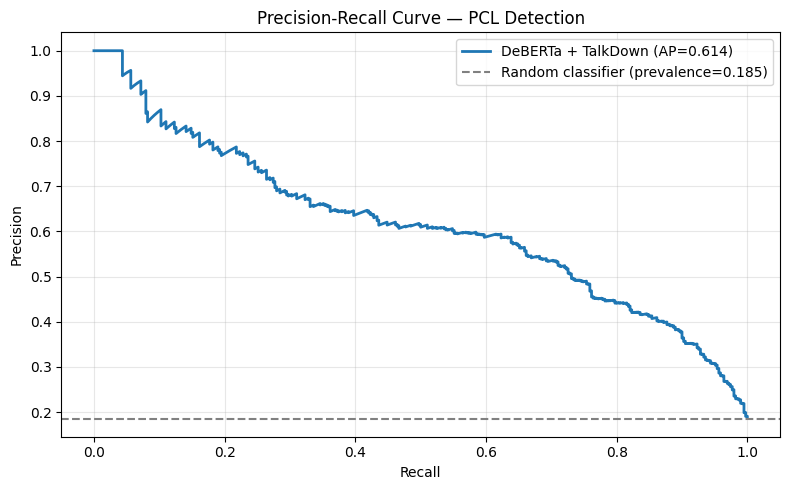

In [18]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(all_labels, all_probs)
ap = average_precision_score(all_labels, all_probs)

plt.figure(figsize=(8, 5))
plt.plot(recall, precision, linewidth=2, label=f'DeBERTa + TalkDown (AP={ap:.3f})')
plt.axhline(y=0.185, color='gray', linestyle='--', label='Random classifier (prevalence=0.185)')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve — PCL Detection')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figures/pr_curve.pdf', bbox_inches='tight')
plt.savefig('figures/pr_curve.png', dpi=150, bbox_inches='tight')
plt.show()

# Mark the operating point at default threshold
default_idx = np.argmin(np.abs(thresholds - 0.5))
print(f'At threshold=0.50: Precision={precision[default_idx]:.3f}, Recall={recall[default_idx]:.3f}')
print(f'At threshold={best_thresh:.2f}: Precision=?, Recall=?')
opt_idx = np.argmin(np.abs(thresholds - best_thresh))
print(f'At threshold={best_thresh:.2f}: Precision={precision[opt_idx]:.3f}, Recall={recall[opt_idx]:.3f}')
print(f'Average Precision: {ap:.4f}')